# Part 4a: Limit Order Book — Data & Demonstration

*"Price is what you pay. Value is what you get. But the order book shows you what everyone else is willing to pay right now."*

---

Parts 1 through 3 worked entirely from end-of-day data: closing prices, daily returns, and macro indicators. The limit order book changes that completely. A limit order is a standing instruction: *I am willing to buy 500 shares of NVDA at $440.00 or better*. The book is the live collection of all such instructions, updated thousands of times per second. It tells you not just what prices traded, but what buyers and sellers *intend* to do — before the trade happens.

This notebook covers only the data side: where it comes from, what each record means, and how to read and visualise the book. Feature engineering and prediction are covered in Parts 4b and 4c.

## Where the Data Comes From

The data is sourced from **Databento**, a market data provider that distributes NASDAQ's ITCH feed in clean, queryable form. NASDAQ ITCH is the raw order-by-order message stream that drives the exchange's matching engine — every limit order add, cancel, modify, and execution is captured at nanosecond precision.

We use two data formats:

**`mbp-1`** (market-by-price, level 1) — records only the best bid and ask at each event. One row per event: millions of rows per stock per day. Used for all feature engineering because it is compact and contains everything needed for level-1 signals.

**`mbp-10`** (market-by-price, 10 levels) — records the top 10 bid and ask price levels. Much larger but needed for depth profile and weighted OBI analysis.

Two time periods are included:

- **Calm period**: October 2–12, 2023 (10 trading days). Normal market conditions, representative of day-to-day microstructure.
- **Stress period**: August 5–9, 2024 (5 trading days). The Bank of Japan rate hike triggered a global carry-trade unwind. VIX spiked to 65 intraday — the highest since the COVID crash. A controlled stress test for every feature built on the calm data.

Stocks covered: NVDA, TSLA, AAPL, MSFT, SPY.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
from scipy import stats

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

LOB_DIR = 'data/lob'

ACTION_LABELS = {'A': 'Add order', 'C': 'Cancel order', 'T': 'Trade', 'F': 'Fill (partial)'}
SIDE_LABELS   = {'B': 'Bid (buy)', 'A': 'Ask (sell)', 'N': 'None (trade)'}

## Understanding the Data

The data comes from NASDAQ's ITCH feed — the raw order-by-order record of every event that changes the book. Each row is not a trade; it is an **event**: an order added, an order cancelled, or an order executed. The book state (bid and ask prices and sizes at up to 10 levels) is recorded *after* each event, so you always know the full book at every point in time.

The key columns are:

**`action`** — what happened: `A` = new limit order added, `C` = limit order cancelled, `T` = trade (an order was matched and executed), `F` = partial fill.

**`side`** — which side was affected: `B` = bid (a buyer's order), `A` = ask (a seller's order), `N` = neither (a cross-trade).

**`bid_px_00` / `ask_px_00`** — best bid and ask price after this event (level 0 = top of book).

**`bid_sz_00` / `ask_sz_00`** — total shares sitting at the best bid and ask.

**`bid_px_01` ... `bid_px_09`** — second through tenth best bid price levels (mbp-10 only). Same for ask.

**`ts_event`** — nanosecond-precision UTC timestamp of the event.


In [2]:
# Load mbp-1 for NVDA (calm period)
nvda = pd.read_parquet(f'{LOB_DIR}/lob_mbp1_NVDA_calm_oct2023.parquet')
nvda.index = nvda.index.tz_convert('US/Eastern')  # convert to market time
nvda['ts_event'] = nvda['ts_event'].dt.tz_convert('US/Eastern')

print(f'NVDA calm: {len(nvda):,} rows  |  {nvda.index[0]}  to  {nvda.index[-1]}')
print(f'Columns  : {list(nvda.columns)}')
nvda[['ts_event','action','side','price','size','bid_px_00','ask_px_00','bid_sz_00','ask_sz_00']].head(50)


NVDA calm: 4,761,024 rows  |  2023-10-02 04:00:00.010216826-04:00  to  2023-10-12 19:59:56.718274004-04:00
Columns  : ['ts_event', 'rtype', 'publisher_id', 'instrument_id', 'action', 'side', 'depth', 'price', 'size', 'flags', 'ts_in_delta', 'sequence', 'bid_px_00', 'ask_px_00', 'bid_sz_00', 'ask_sz_00', 'bid_ct_00', 'ask_ct_00', 'symbol']


,ts_event,action,side,price,size,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00
ts_recv,,,,,,,,,
2023-10-02 04:00:00.010216826-04:00,2023-10-02 04:00:00.010046931-04:00,A,N,403.93,50,403.93,NaN,50,0
2023-10-02 04:00:00.018643514-04:00,2023-10-02 04:00:00.018474714-04:00,A,B,440.77,100,440.77,NaN,100,0
2023-10-02 04:00:00.018676033-04:00,2023-10-02 04:00:00.018507995-04:00,A,A,441.60,100,440.77,441.60,100,100
2023-10-02 04:00:00.019557602-04:00,2023-10-02 04:00:00.019388560-04:00,C,B,440.77,100,403.93,441.60,50,100
2023-10-02 04:00:00.019593199-04:00,2023-10-02 04:00:00.019424923-04:00,A,B,440.73,100,440.73,441.60,100,100
2023-10-02 04:00:00.020198499-04:00,2023-10-02 04:00:00.020030451-04:00,C,B,440.73,100,403.93,441.60,50,100
2023-10-02 04:00:00.020217060-04:00,2023-10-02 04:00:00.020047773-04:00,C,A,441.60,100,403.93,NaN,50,0
2023-10-02 04:00:00.020290689-04:00,2023-10-02 04:00:00.020123216-04:00,A,A,441.63,100,403.93,441.63,50,100
2023-10-02 04:00:00.020794784-04:00,2023-10-02 04:00:00.020626929-04:00,C,A,441.63,100,403.93,NaN,50,0


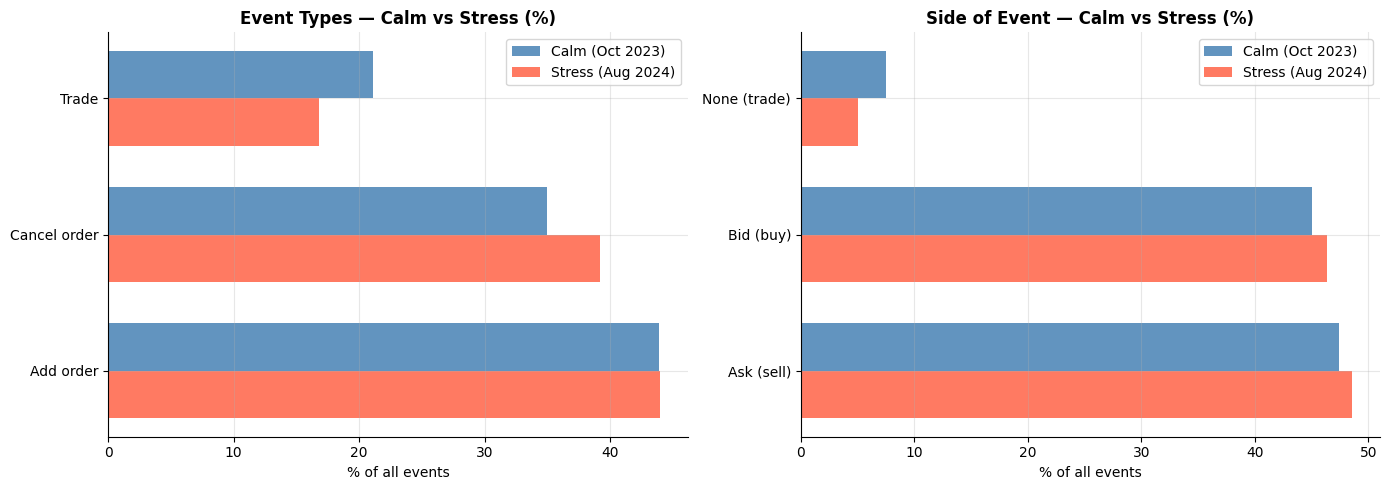

Calm   — total events: 4,761,024  |  trade fill rate: 21.1%
Stress — total events: 17,275,488  |  trade fill rate: 16.8%
Under stress: fewer adds/cancels as a share, higher fraction of trades — market makers pull quotes.


In [3]:
# Event type breakdown — calm vs stress side by side
nvda_stress_early = pd.read_parquet(f'{LOB_DIR}/lob_mbp1_NVDA_stress_aug2024.parquet')
nvda_stress_early.index = nvda_stress_early.index.tz_convert('US/Eastern')

def to_pct(series, total): return series / total * 100

calm_action   = nvda['action'].map(ACTION_LABELS).value_counts()
stress_action = nvda_stress_early['action'].map(ACTION_LABELS).value_counts()
calm_side     = nvda['side'].map(SIDE_LABELS).value_counts()
stress_side   = nvda_stress_early['side'].map(SIDE_LABELS).value_counts()

all_action_cats = sorted(set(calm_action.index) | set(stress_action.index))
all_side_cats   = sorted(set(calm_side.index)   | set(stress_side.index))

# Drop categories where both calm and stress are < 1% (e.g. Fill partial)
def filter_cats(cats, calm_series, stress_series, total_calm, total_stress):
    return [c for c in cats
            if to_pct(calm_series.get(c, 0), total_calm) >= 1
            or to_pct(stress_series.get(c, 0), total_stress) >= 1]

n_calm, n_stress = len(nvda), len(nvda_stress_early)
action_cats = filter_cats(all_action_cats, calm_action, stress_action, n_calm, n_stress)
side_cats   = filter_cats(all_side_cats,   calm_side,   stress_side,   n_calm, n_stress)

calm_a   = [to_pct(calm_action.get(c, 0),   n_calm)   for c in action_cats]
stress_a = [to_pct(stress_action.get(c, 0), n_stress) for c in action_cats]
calm_s   = [to_pct(calm_side.get(c, 0),     n_calm)   for c in side_cats]
stress_s = [to_pct(stress_side.get(c, 0),   n_stress) for c in side_cats]

h = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cats, calm_vals, stress_vals, title in [
    (axes[0], action_cats, calm_a,  stress_a,  'Event Types — Calm vs Stress (%)'),
    (axes[1], side_cats,   calm_s,  stress_s,  'Side of Event — Calm vs Stress (%)')
]:
    y = np.arange(len(cats))
    ax.barh(y + h/2, calm_vals,   height=h, color='steelblue', alpha=0.85, label='Calm (Oct 2023)')
    ax.barh(y - h/2, stress_vals, height=h, color='tomato',    alpha=0.85, label='Stress (Aug 2024)')
    ax.set_yticks(y)
    ax.set_yticklabels(cats)
    ax.set_xlabel('% of all events')
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()

trade_pct_calm   = (nvda['action'] == 'T').sum() / n_calm * 100
trade_pct_stress = (nvda_stress_early['action'] == 'T').sum() / n_stress * 100
print(f'Calm   — total events: {n_calm:,}  |  trade fill rate: {trade_pct_calm:.1f}%')
print(f'Stress — total events: {n_stress:,}  |  trade fill rate: {trade_pct_stress:.1f}%')
print('Under stress: fewer adds/cancels as a share, higher fraction of trades — market makers pull quotes.')

**Key observation:** Under stress period, Add and Cancel events shrink as a share while Trades rise. Market makers pull their resting quotes, aggressive market orders dominate, and the book thins out.

Fill (partial) events (F) are omitted: they account for < 0.1% of events in both periods. NASDAQ ITCH typically breaks partial fills into multiple Trade records rather than issuing F events.

## Visualizing the Book

The order book at any moment can be visualised as a horizontal bar chart: bids on the left (buy orders), asks on the right (sell orders), price increasing away from centre. The gap between the best bid and best ask is the **spread** — the cost of an immediate round-trip trade. The height of each bar is the total quantity sitting at that price level.

For this demonstration, I am using Level 10 data from lob_mbp10_NVDA.parquet to include more levels of the books


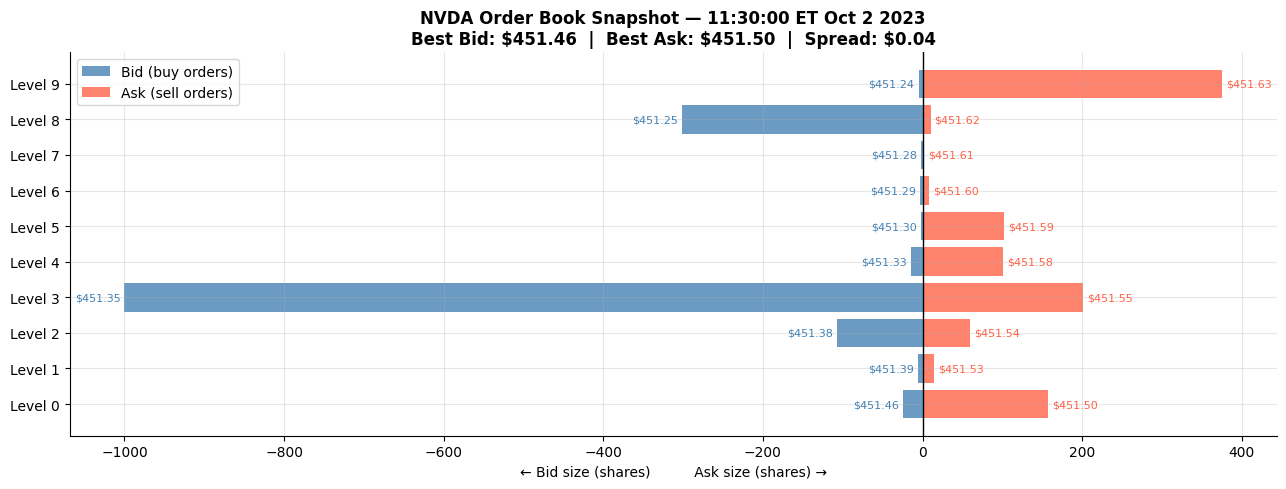

In [4]:
# Load mbp-10 for NVDA, filter to one trading day
nvda10 = pd.read_parquet(f'{LOB_DIR}/lob_mbp10_NVDA.parquet')
nvda10.index = nvda10.index.tz_convert('US/Eastern')

# Pick a mid-session snapshot around 11:30 ET (stable, liquid, representative)
mh = nvda10.loc['2023-10-02'].between_time('09:30', '16:00')
target_time = '11:30'
snap = mh.between_time(target_time, '11:31').iloc[0]

LEVELS = 10
bid_prices = [snap[f'bid_px_{i:02d}'] for i in range(LEVELS)]
ask_prices = [snap[f'ask_px_{i:02d}'] for i in range(LEVELS)]
# Cast to int64 to prevent uint32 overflow on large size values
bid_sizes  = [int(snap[f'bid_sz_{i:02d}']) for i in range(LEVELS)]
ask_sizes  = [int(snap[f'ask_sz_{i:02d}']) for i in range(LEVELS)]

fig, ax = plt.subplots(figsize=(13, 5))
y = range(LEVELS)
ax.barh(y, [-s for s in bid_sizes], left=0, color='steelblue', alpha=0.8, label='Bid (buy orders)')
ax.barh(y, ask_sizes,               left=0, color='tomato',    alpha=0.8, label='Ask (sell orders)')

for i in range(LEVELS):
    if not np.isnan(bid_prices[i]) and bid_sizes[i] > 0:
        ax.text(-bid_sizes[i]-5, i, f'${bid_prices[i]:.2f}', va='center', ha='right', fontsize=8, color='steelblue')
    if not np.isnan(ask_prices[i]) and ask_sizes[i] > 0:
        ax.text(ask_sizes[i]+5,  i, f'${ask_prices[i]:.2f}', va='center', ha='left',  fontsize=8, color='tomato')

ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(range(LEVELS))
ax.set_yticklabels([f'Level {i}' for i in range(LEVELS)])
ax.set_xlabel('← Bid size (shares)          Ask size (shares) →')
spread = ask_prices[0] - bid_prices[0]
ax.set_title(f'NVDA Order Book Snapshot — {snap.name.strftime("%H:%M:%S ET")} Oct 2 2023\n'
             f'Best Bid: ${bid_prices[0]:.2f}  |  Best Ask: ${ask_prices[0]:.2f}  |  Spread: ${spread:.2f}',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## Spread and Mid-Price Dynamics

The snapshot above shows the book at one moment in time. In practice the book updates thousands of times per second — the spread widens and tightens continuously as orders are added and cancelled. Below we track the mid-price and bid-ask spread over a full trading day using the mbp-1 data.

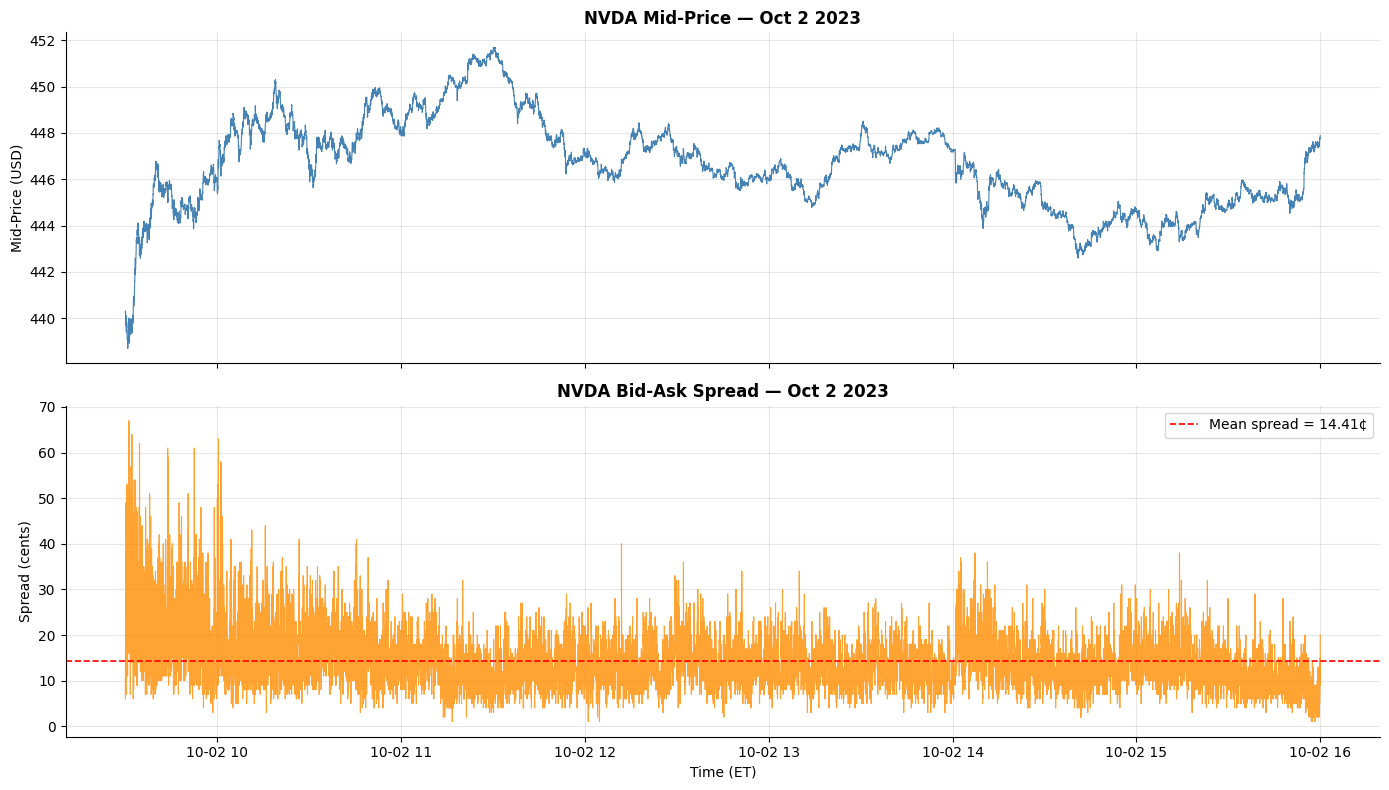

Mean spread : 14.41¢
Open spike  : spread widens at open as market makers hedge their overnight inventory
Intraday    : spread narrows once two-way flow develops


In [5]:
# Spread dynamics over one trading day — filter to regular market hours
day1 = nvda.loc['2023-10-02'].between_time('09:30', '16:00').copy()
day1['spread']   = day1['ask_px_00'] - day1['bid_px_00']
day1['mid']      = (day1['ask_px_00'] + day1['bid_px_00']) / 2

# Resample to 1-second for cleaner plot
spread_1s = day1['spread'].resample('1s').last().dropna()
mid_1s    = day1['mid'].resample('1s').last().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(mid_1s.index, mid_1s, color='steelblue', linewidth=0.8)
axes[0].set_title('NVDA Mid-Price — Oct 2 2023', fontweight='bold')
axes[0].set_ylabel('Mid-Price (USD)')

axes[1].plot(spread_1s.index, spread_1s * 100, color='darkorange', linewidth=0.8, alpha=0.8)
axes[1].axhline(spread_1s.mean() * 100, color='red', linestyle='--', linewidth=1.2,
                label=f'Mean spread = {spread_1s.mean()*100:.2f}¢')
axes[1].set_title('NVDA Bid-Ask Spread — Oct 2 2023', fontweight='bold')
axes[1].set_ylabel('Spread (cents)')
axes[1].set_xlabel('Time (ET)')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f'Mean spread : {spread_1s.mean()*100:.2f}¢')
print(f'Open spike  : spread widens at open as market makers hedge their overnight inventory')
print(f'Intraday    : spread narrows once two-way flow develops')


## Level 1 Features: Spread, Mid-Price, and Order Book Imbalance

Three features fall naturally out of the top of book alone.

The **bid-ask spread** is the most basic liquidity measure: the cost a market order pays to execute immediately. Liquid stocks like AAPL and MSFT maintain spreads of one cent (one tick) for most of the trading day. Higher-beta names like TSLA carry wider spreads and more intraday variation.

The **mid-price** is the average of the best bid and ask. It is the standard reference price in microstructure research because it is not subject to bid-ask bounce: a stock at $100.00 bid / $100.02 ask shows alternating prints at $100.00 and $100.02 even with no true price change, while the mid stays at $100.01 throughout.

**Order Book Imbalance (OBI)** at level 1 is defined as:

$$\text{OBI}_1 = \frac{Q^b_0 - Q^a_0}{Q^b_0 + Q^a_0}$$

where $Q^b_0$ and $Q^a_0$ are the total shares at the best bid and ask. OBI ranges from $-1$ (all volume on the ask side, selling pressure) to $+1$ (all volume on the bid side, buying pressure). It is the single most predictive LOB feature at short horizons and is available from level 1 alone.

### Spread Across Stocks

Spread varies significantly across symbols. Liquid large-caps like AAPL and MSFT trade at one tick (1¢) for most of the day. Higher-beta names like NVDA and TSLA carry wider spreads and more intraday variation. This matters for feature engineering: raw spread values are not comparable across stocks without normalization.

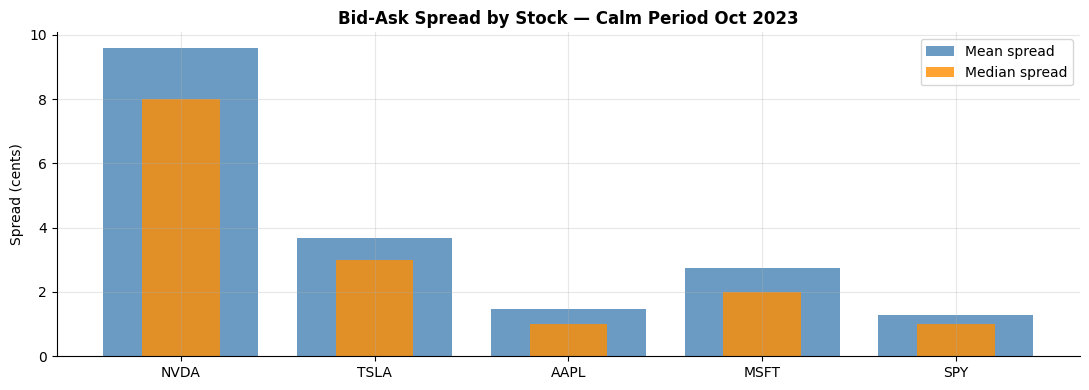

      mean_cents  median_cents  p95_cents
NVDA       9.599           8.0       20.0
TSLA       3.691           3.0        7.0
AAPL       1.480           1.0        2.0
MSFT       2.758           2.0        6.0
SPY        1.274           1.0        2.0


In [6]:
symbols = ['NVDA', 'TSLA', 'AAPL', 'MSFT', 'SPY']

spread_stats = {}
for sym in symbols:
    df = pd.read_parquet(f'{LOB_DIR}/lob_mbp1_{sym}_calm_oct2023.parquet')
    df.index = df.index.tz_convert('US/Eastern')
    mh = df.between_time('09:30','16:00')
    sp = (mh['ask_px_00'] - mh['bid_px_00']).dropna()
    spread_stats[sym] = {'mean_cents': sp.mean()*100, 'median_cents': sp.median()*100,
                         'p95_cents': sp.quantile(0.95)*100}

ss = pd.DataFrame(spread_stats).T
fig, ax = plt.subplots(figsize=(11, 4))
x = range(len(symbols))
ax.bar(x, ss['mean_cents'],   label='Mean spread', color='steelblue', alpha=0.8)
ax.bar(x, ss['median_cents'], label='Median spread', color='darkorange', alpha=0.8, width=0.4)
ax.set_xticks(x)
ax.set_xticklabels(symbols)
ax.set_ylabel('Spread (cents)')
ax.set_title('Bid-Ask Spread by Stock — Calm Period Oct 2023', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
print(ss.round(3))


### Order Book Imbalance Over Time

Spread tells us about liquidity cost. OBI tells us about directional pressure. Below we plot OBI alongside the mid-price and per-second returns for one trading day to see whether imbalance leads price moves.

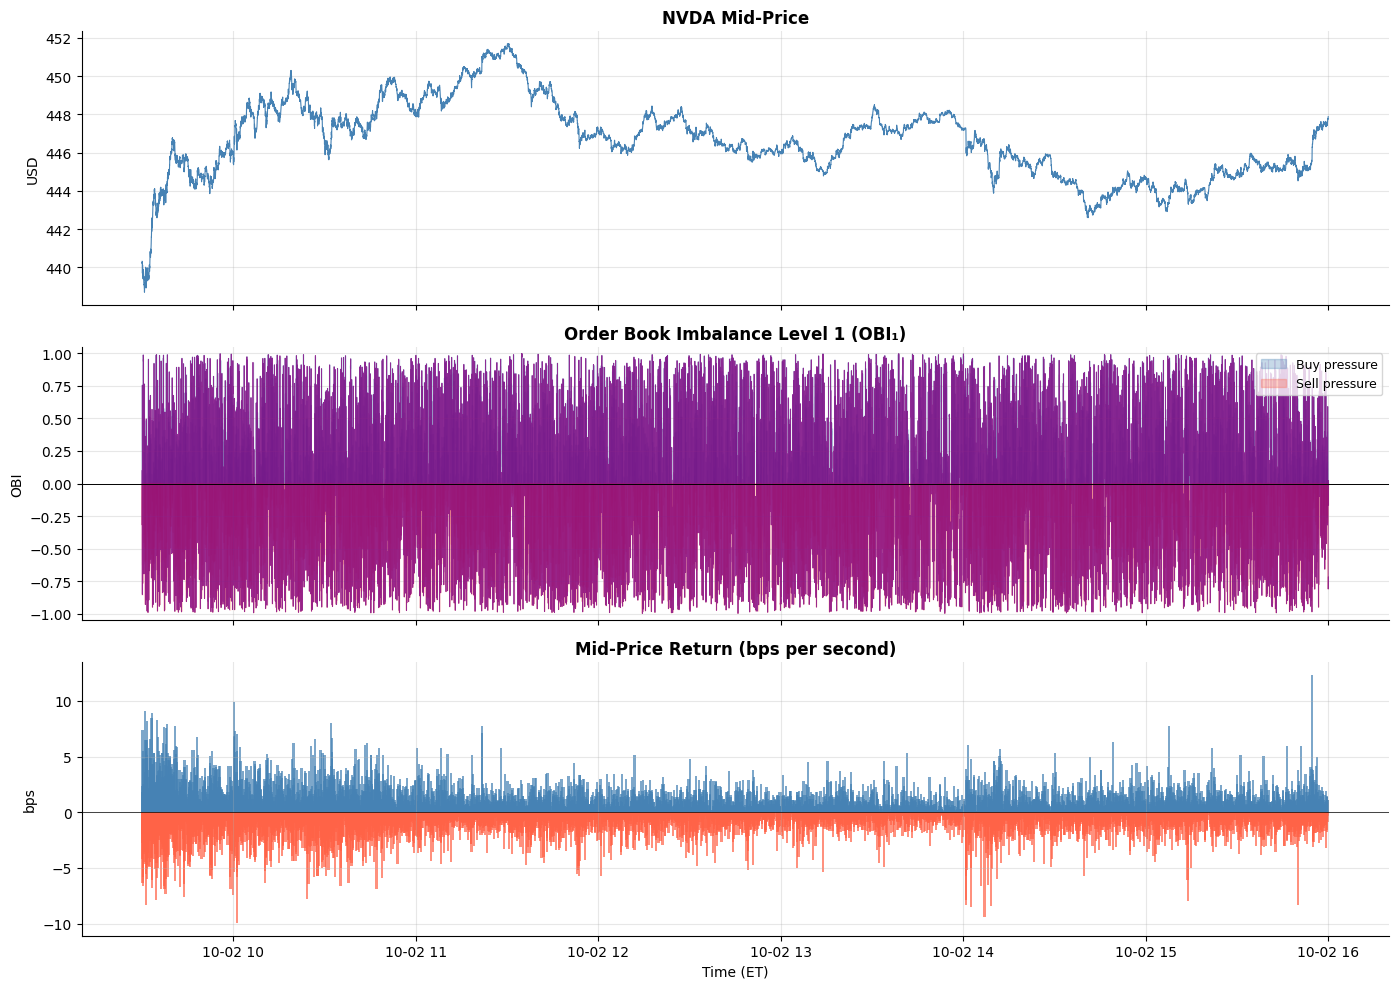

In [7]:
# OBI over time for NVDA — one trading day
day1 = nvda.loc['2023-10-02'].between_time('09:30','16:00').copy()
# Cast to float first: bid_sz_00/ask_sz_00 are uint32, and uint32 subtraction
# wraps around when ask > bid, producing huge positive numbers instead of negatives.
b = day1['bid_sz_00'].astype(float)
a = day1['ask_sz_00'].astype(float)
day1['obi_1'] = (b - a) / (b + a + 1e-10)
day1['mid']   = (day1['bid_px_00'] + day1['ask_px_00']) / 2

# Resample to 1s
obi_1s     = day1['obi_1'].resample('1s').mean().dropna()
mid_1s     = day1['mid'].resample('1s').last().dropna()
mid_ret_1s = mid_1s.pct_change().dropna()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(mid_1s.index, mid_1s, color='steelblue', linewidth=0.8)
axes[0].set_title('NVDA Mid-Price', fontweight='bold')
axes[0].set_ylabel('USD')

axes[1].plot(obi_1s.index, obi_1s, color='purple', linewidth=0.6, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.7)
axes[1].fill_between(obi_1s.index, obi_1s, 0, where=obi_1s>0, color='steelblue', alpha=0.3, label='Buy pressure')
axes[1].fill_between(obi_1s.index, obi_1s, 0, where=obi_1s<0, color='tomato',    alpha=0.3, label='Sell pressure')
axes[1].set_title('Order Book Imbalance Level 1 (OBI₁)', fontweight='bold')
axes[1].set_ylabel('OBI')
axes[1].set_ylim(-1.05, 1.05)
axes[1].legend(fontsize=9)

axes[2].bar(mid_ret_1s.index, mid_ret_1s * 10000, color=[
    'steelblue' if v >= 0 else 'tomato' for v in mid_ret_1s], width=0.0005, alpha=0.7)
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_title('Mid-Price Return (bps per second)', fontweight='bold')
axes[2].set_ylabel('bps')
axes[2].set_xlabel('Time (ET)')
plt.tight_layout()
plt.show()

## What Do Deeper Levels Add?

OBI at level 1 captures the imbalance at the single best bid and ask. But the book has depth: there are orders sitting at prices behind the best, and those orders reveal information that level 1 alone cannot.

**Depth profile**: how much total volume sits on each side across all 10 levels? A book with 50,000 shares on the bid at level 1 but nothing behind it is far more fragile than one with 5,000 shares at each of 10 levels. A large market order in the first case blows through the best bid and moves the price; in the second case it does not.

**Weighted OBI**: rather than using only level 0, compute OBI at each level and weight them. Level 0 carries the most information (it is the price right now); level 9 carries less (it is far from execution). A natural weighting is exponential decay: $w_k = e^{-\alpha k}$.

These features are only available from the mbp-10 data. Below we compare what level 1 alone gives you versus the richer picture from all 10 levels.

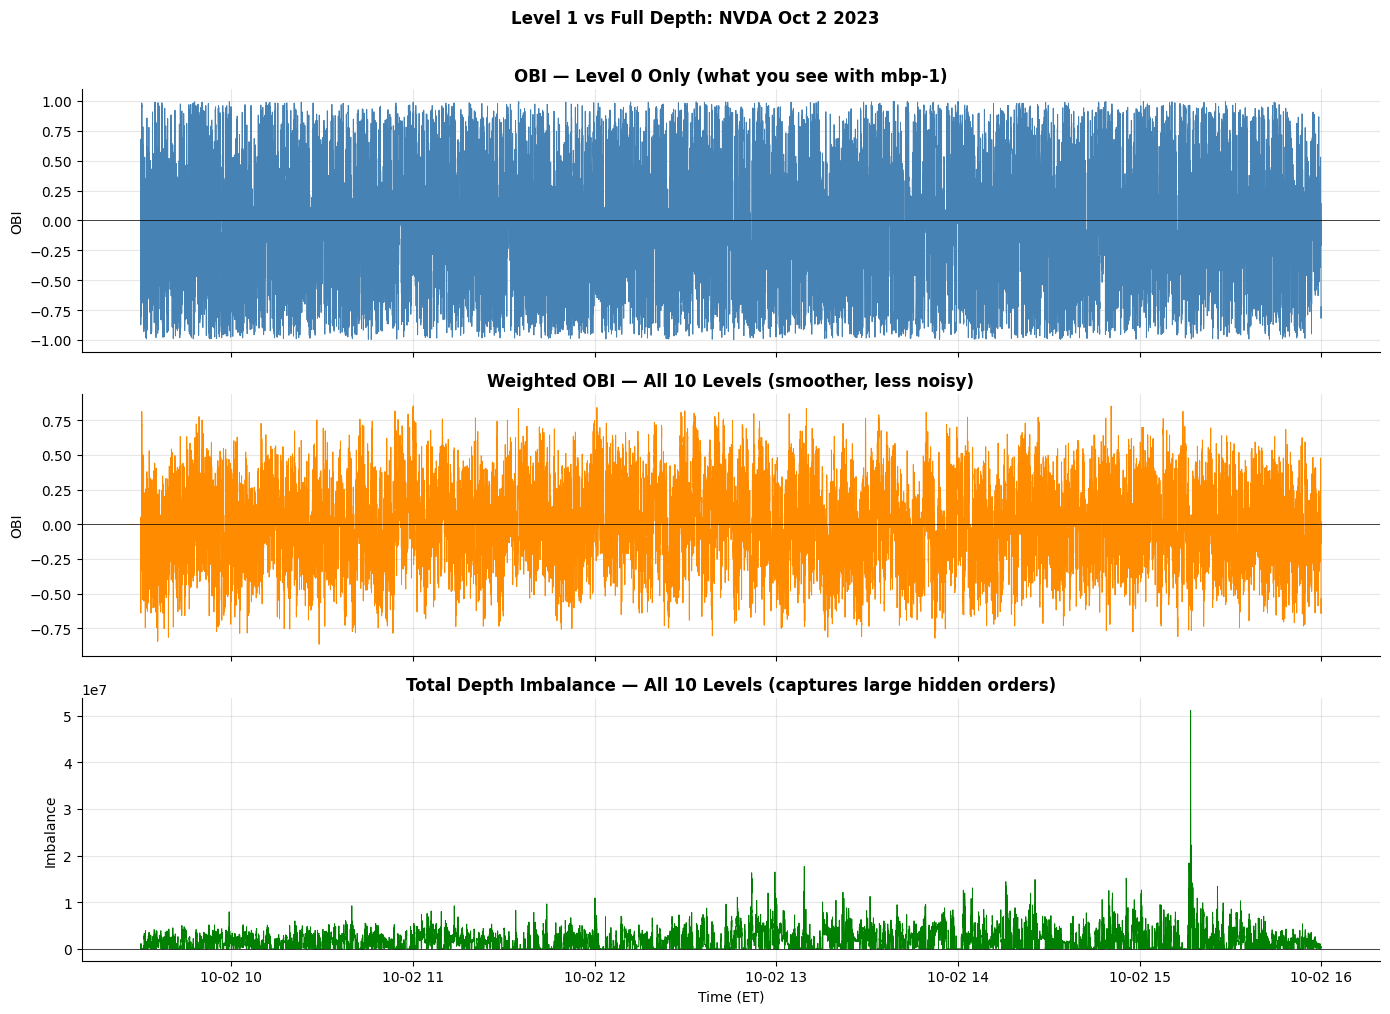

In [8]:
# Load mbp-10 for NVDA, filter to one trading day
nvda10 = pd.read_parquet(f'{LOB_DIR}/lob_mbp10_NVDA.parquet')
nvda10.index = nvda10.index.tz_convert('US/Eastern')
day = nvda10.loc['2023-10-02'].between_time('09:30','16:00').copy()

LEVELS = 10
# ── OBI at each level separately ─────────────────────────────────────────────
for k in range(LEVELS):
    bsz = day[f'bid_sz_{k:02d}'].astype(float)
    asz = day[f'ask_sz_{k:02d}'].astype(float)
    day[f'obi_{k}'] = (bsz - asz) / (bsz + asz + 1e-10)

# ── Weighted OBI (exponential decay) ─────────────────────────────────────────
alpha = 0.5
weights = np.array([np.exp(-alpha * k) for k in range(LEVELS)])
weights /= weights.sum()
obi_cols = [f'obi_{k}' for k in range(LEVELS)]
day['obi_weighted'] = (day[obi_cols].fillna(0) * weights).sum(axis=1)

# ── Total depth each side ─────────────────────────────────────────────────────
day['total_bid_depth'] = sum(day[f'bid_sz_{k:02d}'].fillna(0) for k in range(LEVELS))
day['total_ask_depth'] = sum(day[f'ask_sz_{k:02d}'].fillna(0) for k in range(LEVELS))
day['depth_imbalance'] = (day['total_bid_depth'] - day['total_ask_depth']) / \
                         (day['total_bid_depth'] + day['total_ask_depth'] + 1e-10)

# Resample to 1s
d1s = day[['obi_0','obi_weighted','depth_imbalance']].resample('1s').mean().dropna()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(d1s.index, d1s['obi_0'],          color='steelblue', linewidth=0.7, label='OBI level 0 (top only)')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('OBI — Level 0 Only (what you see with mbp-1)', fontweight='bold')
axes[0].set_ylabel('OBI')

axes[1].plot(d1s.index, d1s['obi_weighted'],    color='darkorange', linewidth=0.7, label='Weighted OBI (10 levels)')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Weighted OBI — All 10 Levels (smoother, less noisy)', fontweight='bold')
axes[1].set_ylabel('OBI')

axes[2].plot(d1s.index, d1s['depth_imbalance'], color='green',      linewidth=0.7, label='Total depth imbalance')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_title('Total Depth Imbalance — All 10 Levels (captures large hidden orders)', fontweight='bold')
axes[2].set_ylabel('Imbalance')
axes[2].set_xlabel('Time (ET)')
plt.suptitle('Level 1 vs Full Depth: NVDA Oct 2 2023', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Depth Profile

The cumulative depth curve shows how much volume is available at each price level away from the mid. A steep curve means volume builds up quickly near the mid — a thick, resilient book. A flat curve means volume is sparse and prices move easily when hit by a large order.

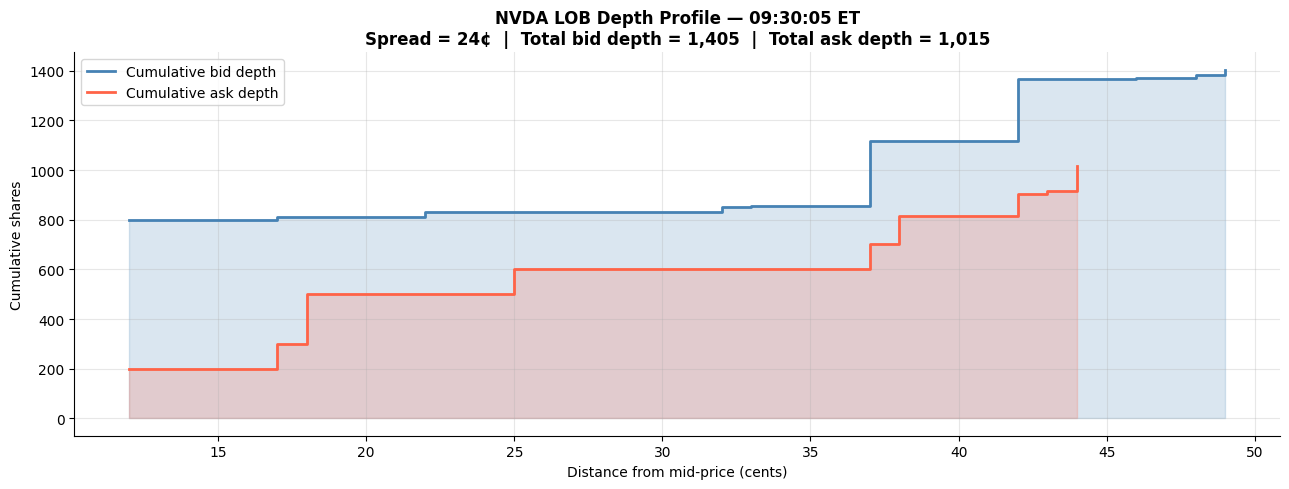

A steep curve = volume builds up quickly near mid = thick resilient book
A flat curve  = volume is sparse = price moves easily when hit by a large order


In [9]:
# LOB depth profile snapshot — what does the book look like at one moment?
snap = day.iloc[1000]   # pick an arbitrary mid-session snapshot

bid_prices = [snap[f'bid_px_{k:02d}'] for k in range(LEVELS)]
ask_prices = [snap[f'ask_px_{k:02d}'] for k in range(LEVELS)]
bid_sizes  = [snap[f'bid_sz_{k:02d}'] for k in range(LEVELS)]
ask_sizes  = [snap[f'ask_sz_{k:02d}'] for k in range(LEVELS)]
mid        = (bid_prices[0] + ask_prices[0]) / 2

# Compute distance from mid in cents
bid_dist = [(mid - p)*100 for p in bid_prices if not np.isnan(p)]
ask_dist = [(p - mid)*100 for p in ask_prices if not np.isnan(p)]
bid_sz   = [s for p, s in zip(bid_prices, bid_sizes) if not np.isnan(p)]
ask_sz   = [s for p, s in zip(ask_prices, ask_sizes) if not np.isnan(p)]

fig, ax = plt.subplots(figsize=(13, 5))
ax.step(bid_dist, np.cumsum(bid_sz), color='steelblue', linewidth=2, label='Cumulative bid depth', where='post')
ax.step(ask_dist, np.cumsum(ask_sz), color='tomato',    linewidth=2, label='Cumulative ask depth', where='post')
ax.fill_between(bid_dist, np.cumsum(bid_sz), alpha=0.2, color='steelblue', step='post')
ax.fill_between(ask_dist, np.cumsum(ask_sz), alpha=0.2, color='tomato',    step='post')
ax.set_xlabel('Distance from mid-price (cents)')
ax.set_ylabel('Cumulative shares')
ax.set_title(f'NVDA LOB Depth Profile — {snap.name.strftime("%H:%M:%S ET")}\n'
             f'Spread = {(ask_prices[0]-bid_prices[0])*100:.0f}¢  |  '
             f'Total bid depth = {sum(bid_sz):,}  |  Total ask depth = {sum(ask_sz):,}',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('A steep curve = volume builds up quickly near mid = thick resilient book')
print('A flat curve  = volume is sparse = price moves easily when hit by a large order')


## Calm vs Stress: August 5, 2024

August 5, 2024 was one of the most volatile single trading days in recent memory. The Bank of Japan unexpectedly raised interest rates, triggering a rapid unwind of the yen carry trade. As the yen surged, forced sellers hit equity markets globally and the VIX spiked to 65 intraday, its highest level since the COVID crash.

We use **SPY** (S&P 500 ETF) for this comparison because it directly captures the broad market reaction. Three things stand out in the data:

1. **Price volatility**: the stress day covers a 2.5% intraday range versus under 0.5% on the calm day.
2. **Spread spike at the open**: SPY's spread jumps to ~27¢ in the first minutes as market makers widen their quotes to protect against uncertainty, then compresses back as two-way flow returns.
3. **OBI instability**: order book imbalance swings more aggressively on the stress day, reflecting the tug-of-war between panic sellers and recovery buyers.

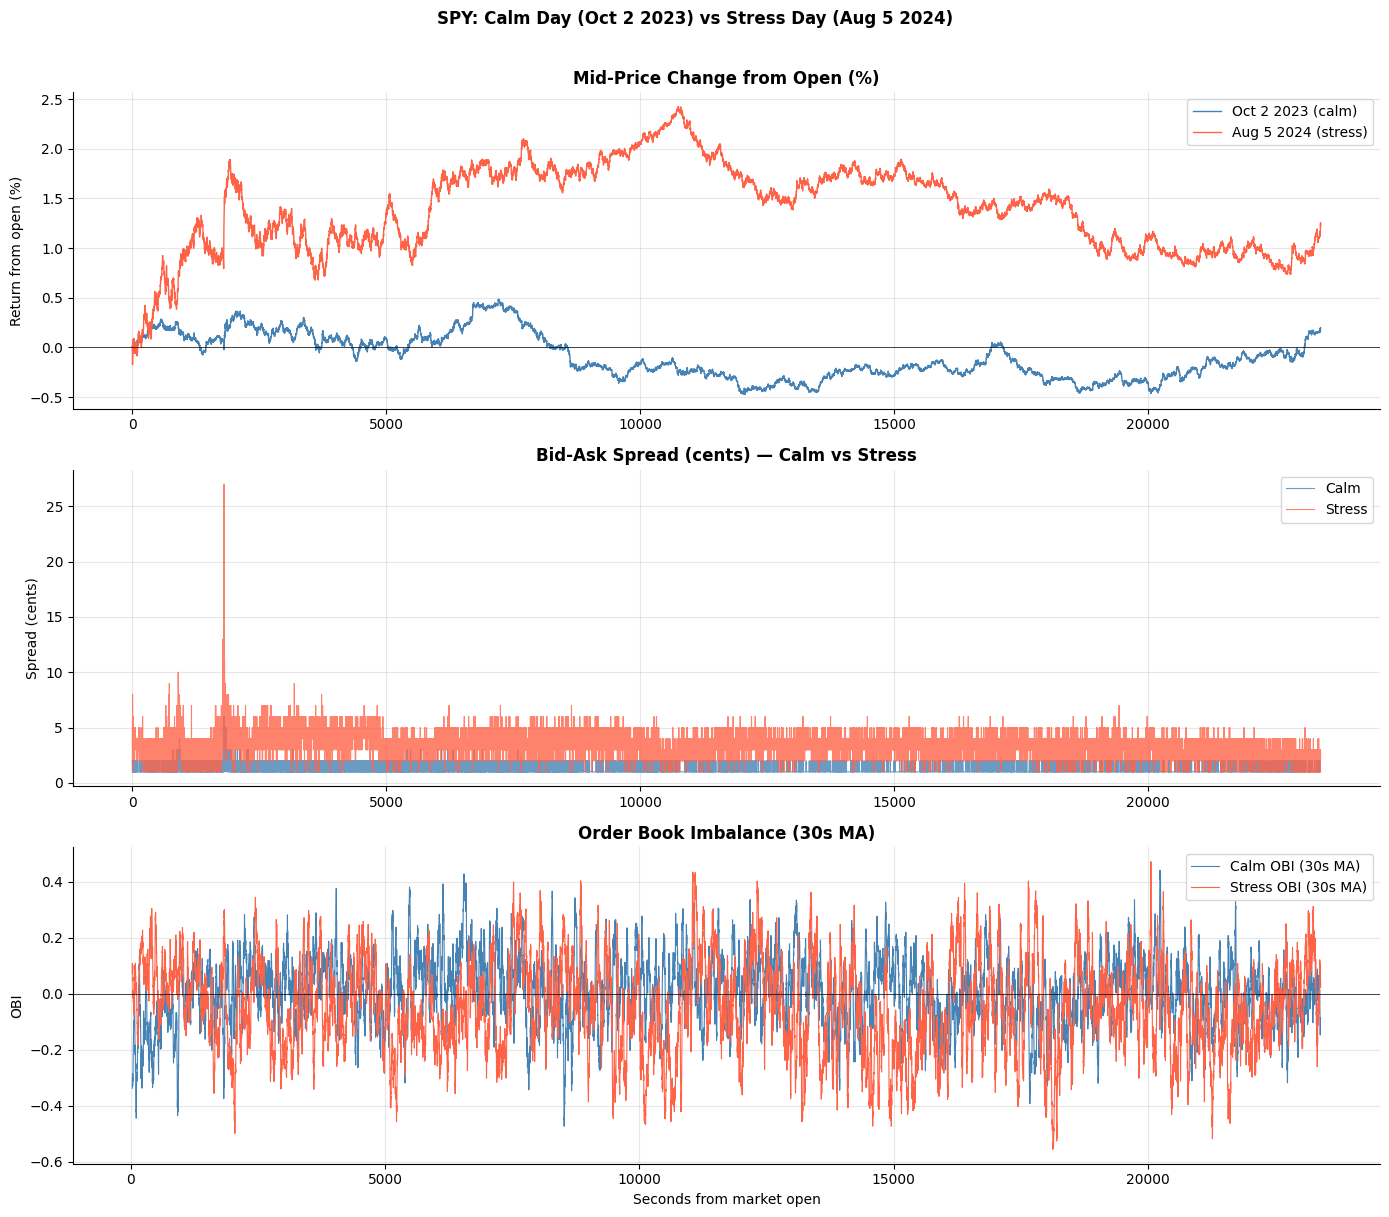

Calm   — mean spread: 1.210¢  |  OBI std: 0.430
Stress — mean spread: 3.466¢  |  OBI std: 0.489


In [10]:
# Load SPY for calm and stress periods
spy_calm   = pd.read_parquet(f'{LOB_DIR}/lob_mbp1_SPY_calm_oct2023.parquet')
spy_stress = pd.read_parquet(f'{LOB_DIR}/lob_mbp1_SPY_stress_aug2024.parquet')
spy_calm.index   = spy_calm.index.tz_convert('US/Eastern')
spy_stress.index = spy_stress.index.tz_convert('US/Eastern')

calm   = spy_calm.loc['2023-10-02'].between_time('09:30','16:00').copy()
stress = spy_stress.loc['2024-08-05'].between_time('09:30','16:00').copy()

for df in [calm, stress]:
    df['spread'] = df['ask_px_00'] - df['bid_px_00']
    bsz = df['bid_sz_00'].astype(np.int64)
    asz = df['ask_sz_00'].astype(np.int64)
    df['obi_1'] = (bsz - asz) / (bsz + asz + 1e-10)
    df['mid']   = (df['bid_px_00'] + df['ask_px_00']) / 2

calm_1s   = calm[['spread','obi_1','mid']].resample('1s').last().dropna()
stress_1s = stress[['spread','obi_1','mid']].resample('1s').last().dropna()

calm_mid_norm   = calm_1s['mid'] / calm_1s['mid'].iloc[0] - 1
stress_mid_norm = stress_1s['mid'] / stress_1s['mid'].iloc[0] - 1

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(range(len(calm_mid_norm)),   calm_mid_norm*100,   color='steelblue', linewidth=1, label='Oct 2 2023 (calm)')
axes[0].plot(range(len(stress_mid_norm)), stress_mid_norm*100, color='tomato',    linewidth=1, label='Aug 5 2024 (stress)')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('Mid-Price Change from Open (%)', fontweight='bold')
axes[0].set_ylabel('Return from open (%)')
axes[0].legend()

axes[1].plot(range(len(calm_1s)),   calm_1s['spread']*100,   color='steelblue', linewidth=0.8, alpha=0.8, label='Calm')
axes[1].plot(range(len(stress_1s)), stress_1s['spread']*100, color='tomato',    linewidth=0.8, alpha=0.8, label='Stress')
axes[1].set_title('Bid-Ask Spread (cents) — Calm vs Stress', fontweight='bold')
axes[1].set_ylabel('Spread (cents)')
axes[1].legend()

axes[2].plot(range(len(calm_1s)),   calm_1s['obi_1'].rolling(30).mean(),   color='steelblue', linewidth=0.8, label='Calm OBI (30s MA)')
axes[2].plot(range(len(stress_1s)), stress_1s['obi_1'].rolling(30).mean(), color='tomato',    linewidth=0.8, label='Stress OBI (30s MA)')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_title('Order Book Imbalance (30s MA)', fontweight='bold')
axes[2].set_ylabel('OBI')
axes[2].set_xlabel('Seconds from market open')
axes[2].legend()
plt.suptitle('SPY: Calm Day (Oct 2 2023) vs Stress Day (Aug 5 2024)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Calm   — mean spread: {calm_1s['spread'].mean()*100:.3f}¢  |  OBI std: {calm_1s['obi_1'].std():.3f}")
print(f"Stress — mean spread: {stress_1s['spread'].mean()*100:.3f}¢  |  OBI std: {stress_1s['obi_1'].std():.3f}")

## Summary

This notebook established the foundations of LOB data:

- The raw feed records every order event at nanosecond precision. Most events are adds and cancels; actual trades are a small fraction.
- The bid-ask spread has a predictable intraday pattern: wide at the open, tight mid-session. It varies significantly across stocks, which rules out using raw values in cross-stock models.
- OBI at level 1 captures directional pressure and visibly leads short-term price moves.
- Deeper levels add information: weighted OBI is smoother and less reactive to single large orders; the cumulative depth profile reveals how resilient the book is to large trades.
- Under stress (Aug 5 2024), all of these characteristics deteriorate simultaneously: spreads blow out, depth collapses, and OBI becomes one-directional.

**Part 4b** turns these observations into features, runs information coefficient analysis, and tests which signals carry predictive power across the calm and stress periods.